In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy import isin
from scipy.stats import linregress
import matplotlib.pyplot as pl
import sys
import os
sys.path.insert(0, os.path.abspath('..')) 
from src.data_related.data_selector import stats_by_generation

# Let us start from the .csv with the minimal amount of data
minimal_df = pd.read_csv('../datasets/processed/pkdx_min.csv', index_col='id')


In [2]:

mean_stage_cat = {}

# Here we define the inputs for the function. We want to check how each mean and median distributes across generations for each pokemon stage in an evolution chain.
conf_stage_cat = {
    "babies2": (["s1c2"], "regular"),
    "babies3":  ([ "s1c3"], "regular"),
    "f2": (["s2c2"], "regular"),
    "inter":   (["s2c3"], "regular"),
    "f3":  (["s3c3"], "regular"),
    "single": (["single"], "regular"),
    "legends": (None, "legendary"),
}

# And we throw a loop to print for each stage the means, medians and everything
for name, (sta, cat) in conf_stage_cat.items():   # ← .items() gives both key and value
    stats = stats_by_generation(minimal_df, category=cat, stage=sta)
    mean_stage_cat[name] = {gen: [values["mean"], values["median"], values["count"]] for gen, values in stats.items()}


# This is to find the overall median per stage and category of all pokes accross all generations.
regular = minimal_df[minimal_df['category'].isin(['regular'])] # mask creation 
legendary = minimal_df[minimal_df['category'].isin(['legendary'])]
regular_baseline = regular.groupby('stage')['total_stats'].median().reset_index()
legendary_baseline = legendary['total_stats'].median()
baseline = [float(regular_baseline['total_stats'][i]) for i in range(6)]
baseline.append(float(legendary_baseline))


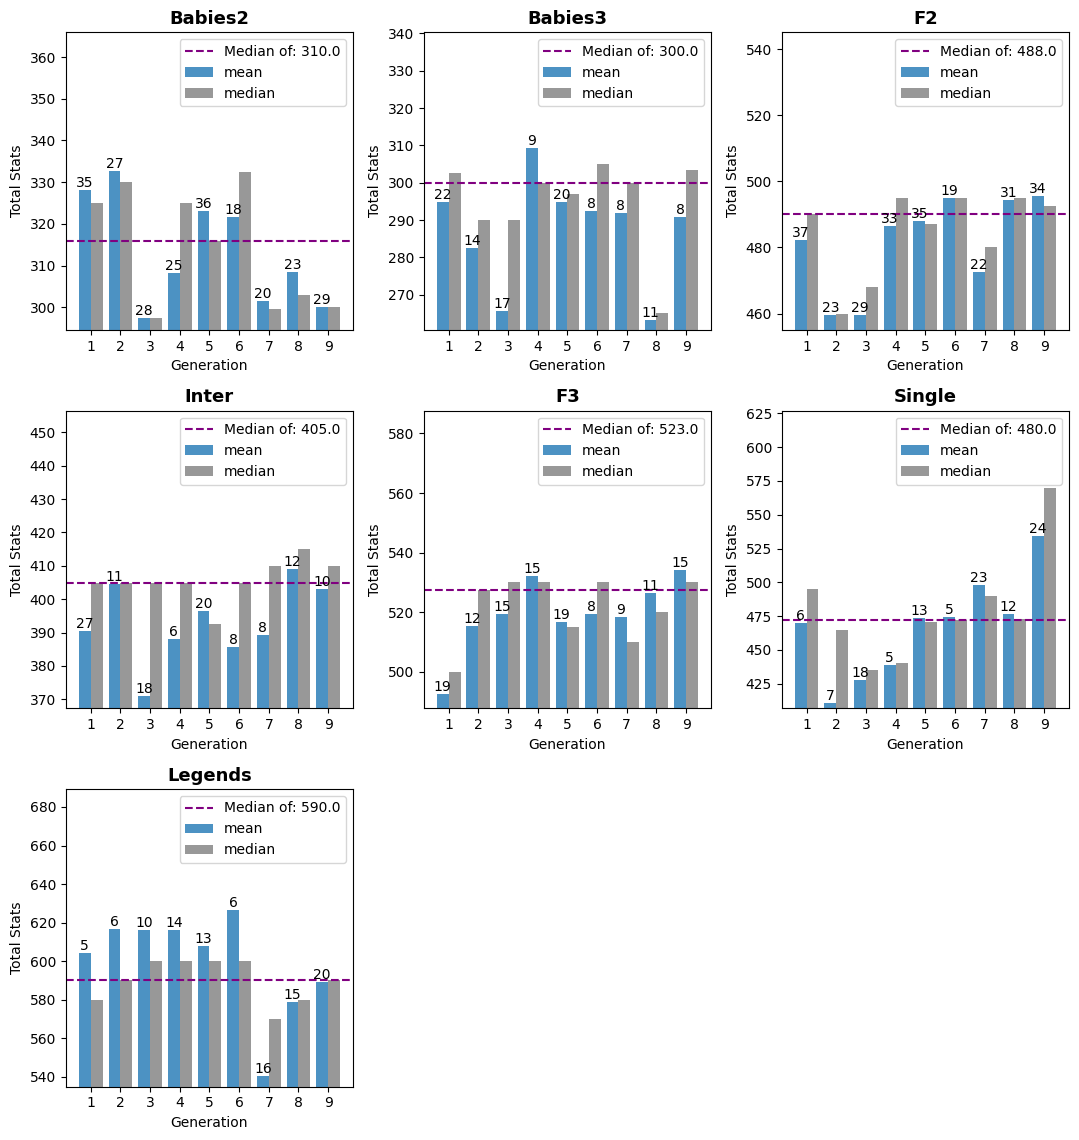

In [3]:
# We then plot previous superdictionary for each stage, the mean and median for each generation.
fig, axes = plt.subplots(3, 3, figsize=(11, 11.5))
axes = axes.flatten()

for idx, (category, gen_data) in enumerate(mean_stage_cat.items()):
    ax = axes[idx]
    
    gens = list(gen_data.keys())
    means = [gen_data[g][0] for g in gens]
    medians = [gen_data[g][1] for g in gens]
    counts = [gen_data[g][-1] for g in gens]

    stage_median_of_medians=np.median(medians)
    
    width = 0.4
    x = np.array(gens)  # convert to array for offset math
    
    # Two bars per generation
    bars1 = ax.bar(x - width/2, means, width, label='mean', alpha=0.8, color= 'C0')
    bars2 = ax.bar(x + width/2, medians, width, label='median', alpha=0.8, color='C7')
    lower_y = min(medians + means)*0.99
    higher_y = max(means + medians) * 1.1
    
    # Add count labels on top of mean bars
    for i, (gen, mean, count) in enumerate(zip(gens, means, counts)):
        ax.text(x[i] - width/2, mean, count, 
                ha='center', va='bottom', fontsize=10)
    
    ax.set_title(f'{category.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Total Stats')
    ax.axhline(stage_median_of_medians, color='purple', linestyle='--',
           linewidth=1.5, label=f'Median of: {baseline[idx]:.1f}')
    ax.set_xticks(x)
    ax.set_ylim(lower_y, higher_y)
    ax.legend()

plt.tight_layout()
axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.savefig('../plots/bst_dist.png') # Save it to avoid issues.
plt.show()

In [4]:
# There seems to be trends for singles and F3. Let see what happens if we fit.

# Extract the means and medians and store means and medians in a list
gens_fit = np.array(range(1,10,1))  # [1,2,3,...,9]
means_fit = np.array([d[0] for d in mean_stage_cat['f3'].values()])  # mean 
medians_fit = np.array([d[1] for d in mean_stage_cat['f3'].values()])  # median 
values_plot = [means_fit, medians_fit]

# Fit for x, which represent the generations. Last arg is the rank of the fit. Try 4
mean_coeffs = np.polyfit(x, means_fit, 3)
median_coeffs = np.polyfit(x, medians_fit, 3)

# And generate the curve for the previous fitting. Save those curves.
curve_mean = np.poly1d(mean_coeffs)
curve_median = np.poly1d(median_coeffs)
curve_plot = [curve_mean, curve_median]

# From the correlation matrix, compute the square of the cross term
rsquare=[np.corrcoef(means_fit, curve_mean(gens))[1,0]**2, 
         np.corrcoef(medians_fit, curve_median(gens))[1,0]**2]


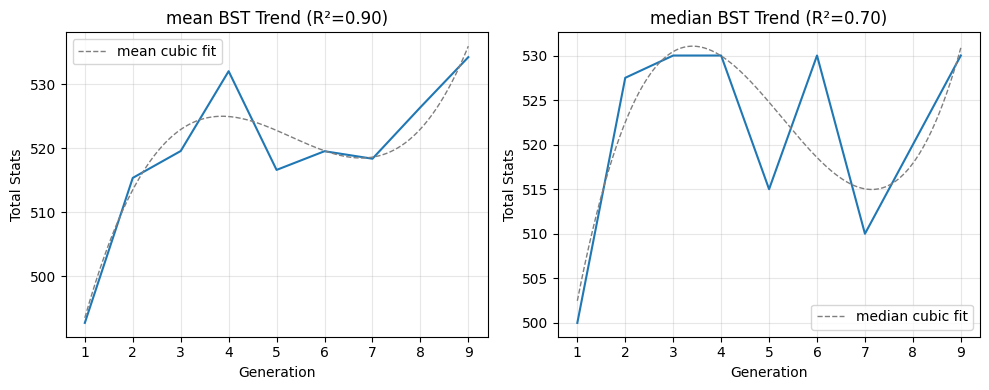

In [5]:
# And now plot. Generate a smooth x for plotting the values and the fit.

x_smooth = np.linspace(1,9,300)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['mean', 'median']

for n in range(len(values_plot)):
    ax = axes[n]
    
    
    ax.plot(gens_fit, values_plot[n])
    ax.plot(x_smooth, curve_plot[n](x_smooth), 'C7--', linewidth=1, label=f'{labels[n]} cubic fit')
    
    ax.set_title(f'{labels[n]} BST Trend (R²={rsquare[n]:.2f})')  # Add your R²
    ax.set_xlabel('Generation')
    ax.set_ylabel('Total Stats')
    ax.legend()
    ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../plots/bst_f3_fit.png')   

In [6]:
# Let us check same thing for Singles. As we see, from Gen 3 onwards, we see a realistic increment for this type of pokemon. Let me manually drop first two gens:

# OBS! mns = mean(s)
# OBS! mds = medians(s)

# This is the value of the generation from which we see the incremental tendency.
GEN_DROP = 2

mns_sing_fit = np.array([d[0] for d in mean_stage_cat['single'].values()])  # mean 
mds_sing_fit = np.array([d[1] for d in mean_stage_cat['single'].values()])  # median
mns_sing_fit = mns_sing_fit[GEN_DROP:]
mds_sing_fit = mds_sing_fit[GEN_DROP:]
v_sing_plt = [mns_sing_fit, mds_sing_fit]
new_gens_fit = gens_fit[GEN_DROP:]

# Fit for x, which represent the generations. Last arg is the rank of the fit. Try 4
mns_sing_coeffs = np.polyfit(new_gens_fit, mns_sing_fit, 1)
mds_sing_coeffs = np.polyfit(new_gens_fit, mds_sing_fit, 1)

# And generate the linear fit for the previous fitting. Save those curves.
line_mns_sing = np.poly1d(mns_sing_coeffs)
line_mds_sing = np.poly1d(mds_sing_coeffs)
lines_plot= [line_mns_sing, line_mds_sing]

# From the correlation matrix, compute the square of the cross term
rsquare=[np.corrcoef(mns_sing_fit, line_mns_sing(new_gens_fit))[0,1]**2, 
         np.corrcoef(mds_sing_fit, line_mds_sing(new_gens_fit))[1,0]**2]


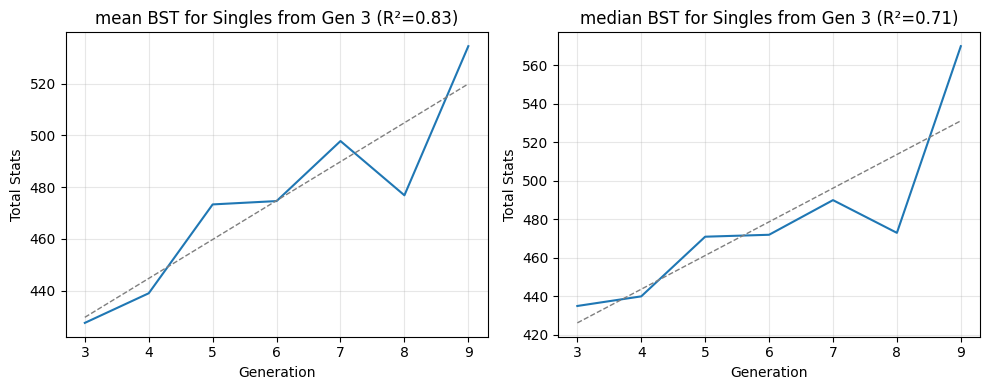

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['mean', 'median']
x_sing = np.linspace(GEN_DROP +1,9,300) # Because lists start counting on 0.
for n in range(len(v_sing_plt)):
    ax = axes[n]
    
    
    ax.plot(new_gens_fit, v_sing_plt[n])
    ax.plot(x_sing, lines_plot[n](x_sing), 'C7--', linewidth=1, label=f'{labels[n]} cubic fit')
    
    ax.set_title(f'{labels[n]} BST for Singles from Gen {GEN_DROP +1 } (R²={rsquare[n]:.2f})')  # Add your R²
    ax.set_xlabel('Generation')
    ax.set_ylabel('Total Stats')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/bst_single_fit.png')